In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

# Set style untuk visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load data hasil scraping Phase 1
df = pd.read_csv('/kaggle/input/eda-shopee/shopee_reviews_phase1.csv')

print(f"📊 Dataset loaded: {len(df)} reviews")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few reviews:")
print(df[['content', 'score']].head())

# Filter hanya review yang ada contentnya
df = df[df['content'].notna() & (df['content'].str.strip() != '')]
print(f"\n✅ After filtering empty reviews: {len(df)} reviews")

📊 Dataset loaded: 1000 reviews
Columns: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']

First few reviews:
                                             content  score
0  aplikasi shopee ini sangat bagus karena. bisa ...      5
1  suka belanja di shopee.. terpercaya dan pengem...      5
2  sangat buruk untuk jasa pengiriman shopee spx....      1
3  Shopee tdk melindungi pembeli dan komplain pen...      1
4                             ok banget terima kasih      5

✅ After filtering empty reviews: 1000 reviews


In [3]:
!pip install Sastrawi emoji unidecode pyahocorasick nltk -q

import pandas as pd
import numpy as np
import os
import re
import sys
import json
import time
import pickle
import hashlib
import tempfile
from io import StringIO
from datetime import datetime, timezone
from pathlib import Path

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import emoji
from unidecode import unidecode
import ahocorasick

# Request handling
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

print("✅ All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.0 MB/s eta 0:00:00
✅ All libraries imported successfully!


In [4]:
# Setup directories
PROJECT_DIR = "/kaggle/working"
CACHE_DIR = os.path.join(PROJECT_DIR, "automaton_cache")
LOCAL_SLANG_CSV = os.path.join(CACHE_DIR, "slang_dict_loaded.csv")
LOCAL_SLANG_PKL = os.path.join(CACHE_DIR, "slang_dict_loaded.pkl")
AUTOMATON_PKL = os.path.join(CACHE_DIR, "automaton.pkl")
METADATA_JSON = os.path.join(CACHE_DIR, "slang_metadata.json")

MAX_CACHE_AGE_DAYS = 30

SLANG_URLS = [
    "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv",
    "https://raw.githubusercontent.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/master/new_kamusalay.csv"
]

os.makedirs(CACHE_DIR, exist_ok=True)

# Initialize stemmer and stopwords\
factory = StopWordRemoverFactory()
INDO_STOPWORDS = factory.get_stop_words()
stemmer = StemmerFactory().create_stemmer()

# Custom stopwords to add (opsional - tambahkan kata yang tidak informatif)
CUSTOM_STOPWORDS = {
    'nya', 'lah', 'kah', 'tapi', 'tp', 'tpi', 'ini', 'itu', 
    'sih', 'kok', 'dong', 'deh', 'yg', 'utk', 'dgn', 'krn',
    'udah', 'sudah', 'belum', 'akan', 'telah'
}
INDO_STOPWORDS = set(factory.get_stop_words())  # ubah list menjadi set
INDO_STOPWORDS.update(CUSTOM_STOPWORDS)         # sekarang bisa update

print("✅ Configuration loaded!")
print(f"📁 Cache directory: {CACHE_DIR}")
print(f"📚 Indonesian stopwords: {len(INDO_STOPWORDS)} words")

✅ Configuration loaded!
📁 Cache directory: /kaggle/working/automaton_cache
📚 Indonesian stopwords: 136 words


In [5]:
# Method 1: NLTK
from nltk.corpus import stopwords
nltk_stopwords = set(stopwords.words('indonesian'))

# Method 2: Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
factory = StopWordRemoverFactory()
sastrawi_stopwords = factory.get_stop_words()

# Bandingkan
print(f"NLTK stopwords: {len(nltk_stopwords)} words")
print(f"Sastrawi stopwords: {len(sastrawi_stopwords)} words")

NLTK stopwords: 757 words
Sastrawi stopwords: 126 words


In [6]:
# Ambil sample review
sample_reviews = df['content'].head(10).tolist()

print("="*70)
print("COMPARISON: NLTK vs SASTRAWI vs MINIMAL STOPWORDS")
print("="*70)

# Setup
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk_stopwords = set(stopwords.words('indonesian'))
factory = StopWordRemoverFactory()
sastrawi_stopwords = set(factory.get_stop_words())
minimal_stopwords = {'nya', 'lah', 'kah', 'sih', 'dong', 'deh', 'kok',
                     'yg', 'dgn', 'utk', 'krn', 'pd', 'ke', 'dari', 'di'}

for i, review in enumerate(sample_reviews, 1):
    if not review or not isinstance(review, str):
        continue
    
    # Preprocessing basic (lowercase, normalize)
    text = review.lower().strip()
    tokens = text.split()
    
    # Apply different stopword removal
    nltk_result = [w for w in tokens if w not in nltk_stopwords]
    sastrawi_result = [w for w in tokens if w not in sastrawi_stopwords]
    minimal_result = [w for w in tokens if w not in minimal_stopwords]
    
    print(f"\nReview {i}:")
    print(f"Original ({len(tokens)} words):")
    print(f"  {review[:100]}...")
    print(f"\nNLTK ({len(nltk_result)} words remaining):")
    print(f"  {' '.join(nltk_result[:15])}...")
    print(f"\nSastrawi ({len(sastrawi_result)} words remaining):")
    print(f"  {' '.join(sastrawi_result[:15])}...")
    print(f"\nMinimal ({len(minimal_result)} words remaining):")
    print(f"  {' '.join(minimal_result[:15])}...")
    print("-"*70)

COMPARISON: NLTK vs SASTRAWI vs MINIMAL STOPWORDS

Review 1:
Original (23 words):
  aplikasi shopee ini sangat bagus karena. bisa mempermudah kita jika ingin belanja namun malas keluar...

NLTK (13 words remaining):
  aplikasi shopee bagus karena. mempermudah belanja malas rumah gratis ongkir pokoknya bagus banget...

Sastrawi (15 words remaining):
  aplikasi shopee sangat bagus karena. mempermudah belanja malas keluar rumah gratis ongkir pokoknya bagus banget...

Minimal (23 words remaining):
  aplikasi shopee ini sangat bagus karena. bisa mempermudah kita jika ingin belanja namun malas keluar...
----------------------------------------------------------------------

Review 2:
Original (15 words):
  suka belanja di shopee.. terpercaya dan pengembalian dana yang mudah apabila barang tidak sesuai dis...

NLTK (10 words remaining):
  suka belanja shopee.. terpercaya pengembalian dana mudah barang sesuai diskripsi.....

Sastrawi (11 words remaining):
  suka belanja shopee.. terpercaya pen

In [7]:
def compute_sha1(text):
    """Compute SHA1 hash of text"""
    return hashlib.sha1(text.encode('utf-8')).hexdigest()

def atomic_write_text(path, text, enc='utf-8'):
    """Atomic file write for text"""
    dirn = os.path.dirname(path)
    os.makedirs(dirn, exist_ok=True)
    fd, tmp = tempfile.mkstemp(dir=dirn)
    try:
        with os.fdopen(fd, 'w', encoding=enc) as f:
            f.write(text)
        os.replace(tmp, path)
    except Exception:
        try:
            os.remove(tmp)
        except:
            pass
        raise

def atomic_write_pickle(path, obj):
    """Atomic file write for pickle"""
    dirn = os.path.dirname(path)
    os.makedirs(dirn, exist_ok=True)
    fd, tmp = tempfile.mkstemp(dir=dirn)
    try:
        with os.fdopen(fd, 'wb') as f:
            pickle.dump(obj, f)
        os.replace(tmp, path)
    except Exception:
        try:
            os.remove(tmp)
        except:
            pass
        raise

def make_session_with_retry(retries=3, backoff_factor=0.3):
    """Create requests session with retry logic"""
    session = requests.Session()
    retry = Retry(
        total=retries,
        read=retries,
        connect=retries,
        backoff_factor=backoff_factor,
        status_forcelist=(500, 502, 504)
    )
    adapter = HTTPAdapter(max_retries=retry)
    session.mount('http://', adapter)
    session.mount('https://', adapter)
    return session

print("✅ Helper functions loaded!")

✅ Helper functions loaded!


In [8]:
def conditional_fetch_text(url, session, prev_info=None, timeout=15):
    """Conditional fetch with ETag/Last-Modified support"""
    headers = {}
    if prev_info:
        if prev_info.get('etag'):
            headers['If-None-Match'] = prev_info.get('etag')
        elif prev_info.get('last_modified'):
            headers['If-Modified-Since'] = prev_info.get('last_modified')
    try:
        r = session.get(url, headers=headers, timeout=timeout)
        if r.status_code == 304:
            return 'not_modified', None, {'status_code':304, 'url':url}
        if r.status_code == 200:
            text = r.text
            info = {
                'status_code':200,
                'etag': r.headers.get('ETag'),
                'last_modified': r.headers.get('Last-Modified'),
                'sha1': compute_sha1(text),
                'url': url
            }
            return 'fetched', text, info
        return 'error', None, {'status_code': r.status_code, 'url': url}
    except Exception as e:
        return 'error', None, {'error': str(e), 'url': url}

def load_mapping_with_metadata(urls, cache_csv=LOCAL_SLANG_CSV, cache_pkl=LOCAL_SLANG_PKL, 
                               metadata_json=METADATA_JSON, session=None, max_age_days=30):
    """Load slang mapping with caching"""
    if session is None:
        session = make_session_with_retry()
    
    meta = {}
    if os.path.exists(metadata_json):
        try:
            with open(metadata_json, 'r', encoding='utf-8') as f:
                meta = json.load(f)
        except Exception:
            meta = {}
    
    age_days = None
    if meta.get('fetched_at'):
        try:
            iso = meta['fetched_at']
            if iso.endswith('Z'):
                iso = iso.replace('Z', '+00:00')
            fetched_dt = datetime.fromisoformat(iso)
            age_days = (datetime.now(timezone.utc) - fetched_dt).days
        except Exception:
            age_days = None
    
    if os.path.exists(cache_pkl) and age_days is not None and age_days < max_age_days:
        try:
            with open(cache_pkl, 'rb') as f:
                mapping = pickle.load(f)
            print(f"📂 Using cached slang dictionary (age: {age_days} days, entries: {len(mapping)})")
            return mapping, meta
        except Exception as e:
            print(f"⚠️ Failed loading cache: {e}")
    
    combined_mapping = {}
    if os.path.exists(cache_pkl):
        try:
            with open(cache_pkl, 'rb') as f:
                combined_mapping = pickle.load(f) or {}
        except Exception:
            combined_mapping = {}
    
    prev_sources = {s.get('url'): s for s in meta.get('sources', [])} if meta.get('sources') else {}
    updated = False
    new_sources_meta = []
    
    print("📥 Fetching slang dictionaries...")
    for url in urls:
        prev_info = prev_sources.get(url, {})
        status, text, info = conditional_fetch_text(url, session, prev_info=prev_info)
        
        if status == 'not_modified':
            print(f"  ✅ {url.split('/')[-1]}: Not modified (using cache)")
            new_sources_meta.append(prev_info)
            continue
        
        if status == 'fetched' and text:
            try:
                df = pd.read_csv(StringIO(text))
                txt_cols = [c for c in df.columns if df[c].dtype == object]
                if len(txt_cols) >= 2:
                    new_map = dict(zip(df[txt_cols[0]].astype(str).str.strip().str.lower(),
                                       df[txt_cols[1]].astype(str).str.strip().str.lower()))
                else:
                    df = df.astype(str)
                    new_map = dict(zip(df.iloc[:,0].str.strip().str.lower(), 
                                      df.iloc[:,1].str.strip().str.lower()))
                combined_mapping.update(new_map)
                new_sources_meta.append(info)
                updated = True
                print(f"  ✅ {url.split('/')[-1]}: Fetched {len(new_map)} entries")
            except Exception as e:
                print(f"  ❌ {url.split('/')[-1]}: Failed - {e}")
                new_sources_meta.append({'url':url, 'error': str(e)})
        else:
            new_sources_meta.append(info)
    
    if updated or not os.path.exists(cache_pkl):
        try:
            df_save = pd.DataFrame(list(combined_mapping.items()), columns=['slang','formal'])
            df_save.to_csv(cache_csv, index=False, encoding='utf-8-sig')
            atomic_write_pickle(cache_pkl, combined_mapping)
            
            meta_new = {
                'sources': new_sources_meta,
                'fetched_at': datetime.now(timezone.utc).isoformat(),
                'num_entries': len(combined_mapping),
                'sha1': compute_sha1(json.dumps(sorted(list(combined_mapping.items())), 
                                                ensure_ascii=False))
            }
            atomic_write_text(metadata_json, json.dumps(meta_new, indent=2, ensure_ascii=False))
            print(f"💾 Saved slang dictionary: {len(combined_mapping)} entries")
            return combined_mapping, meta_new
        except Exception as e:
            print(f"⚠️ Failed to persist cache: {e}")
    
    return combined_mapping, meta

print("✅ Slang loading functions ready!")

✅ Slang loading functions ready!


In [9]:
def build_aho_automaton(mapping):
    """Build Aho-Corasick automaton for efficient string matching"""
    if not mapping:
        return None
    clean_map = {str(k).strip().lower(): str(v).strip().lower() 
                 for k,v in mapping.items() if str(k).strip() != ""}
    A = ahocorasick.Automaton()
    for key, val in clean_map.items():
        A.add_word(key, (key, val))
    start = time.time()
    A.make_automaton()
    elapsed = time.time() - start
    print(f"⚙️ Built Aho-Corasick automaton: {len(clean_map)} patterns in {elapsed:.3f}s")
    return A

def safe_load_or_rebuild_automaton(mapping, automaton_pkl=AUTOMATON_PKL, 
                                   metadata_json=METADATA_JSON):
    """Load or rebuild automaton with caching"""
    current_sha = compute_sha1(json.dumps(sorted(list(mapping.items())), 
                                          ensure_ascii=False))
    meta = {}
    if os.path.exists(metadata_json):
        try:
            with open(metadata_json, 'r', encoding='utf-8') as f:
                meta = json.load(f)
        except Exception:
            meta = {}
    
    meta_sha = meta.get('sha1')
    if os.path.exists(automaton_pkl) and meta_sha == current_sha:
        try:
            with open(automaton_pkl, 'rb') as f:
                automaton = pickle.load(f)
            print("📂 Loaded cached automaton")
            return automaton
        except Exception as e:
            print(f"⚠️ Failed loading automaton cache: {e}. Rebuilding...")
    
    automaton = build_aho_automaton(mapping)
    try:
        atomic_write_pickle(automaton_pkl, automaton)
        meta['automaton_saved_at'] = datetime.now(timezone.utc).isoformat()
        atomic_write_text(metadata_json, json.dumps(meta, indent=2, ensure_ascii=False))
        print("💾 Saved automaton to cache")
    except Exception as e:
        print(f"⚠️ Could not cache automaton: {e}")
    
    return automaton

print("✅ Automaton functions ready!")

✅ Automaton functions ready!


In [10]:
print("\n" + "="*70)
print("🔧 INITIALIZING SLANG NORMALIZATION")
print("="*70 + "\n")

SLANG_DICT, meta = load_mapping_with_metadata(
    SLANG_URLS, 
    cache_csv=LOCAL_SLANG_CSV, 
    cache_pkl=LOCAL_SLANG_PKL, 
    metadata_json=METADATA_JSON, 
    session=make_session_with_retry(), 
    max_age_days=MAX_CACHE_AGE_DAYS
)

print(f"\n✅ Slang dictionary loaded: {len(SLANG_DICT)} entries")

automaton = safe_load_or_rebuild_automaton(
    SLANG_DICT, 
    automaton_pkl=AUTOMATON_PKL, 
    metadata_json=METADATA_JSON
)

print(f"✅ Automaton ready: {automaton is not None}\n")


🔧 INITIALIZING SLANG NORMALIZATION

📥 Fetching slang dictionaries...
  ✅ colloquial-indonesian-lexicon.csv: Fetched 4330 entries
  ✅ new_kamusalay.csv: Fetched 15166 entries
💾 Saved slang dictionary: 15623 entries

✅ Slang dictionary loaded: 15623 entries
⚙️ Built Aho-Corasick automaton: 15623 patterns in 0.007s
💾 Saved automaton to cache
✅ Automaton ready: True



In [11]:
_token_pat = re.compile(r'\w+', flags=re.UNICODE)

def token_based_replace(text, mapping):
    """Token-based slang replacement"""
    if not isinstance(text, str) or not mapping:
        return text
    def repl_token(m):
        tok = m.group(0)
        lower = tok.lower()
        if lower in mapping:
            return mapping[lower]
        return tok
    return _token_pat.sub(repl_token, text)

def aho_phrase_replace(text, automaton, mapping, whole_word=True):
    """Aho-Corasick based phrase replacement"""
    if automaton is None or not mapping:
        return text.lower() if isinstance(text, str) else text
    
    lower_text = text.lower()
    matches = []
    
    for end_idx, val in automaton.iter(lower_text):
        key, replacement = val
        start_idx = end_idx - len(key) + 1
        
        if whole_word:
            before_ok = (start_idx == 0) or (not re.match(r'\w', lower_text[start_idx-1]))
            after_ok = (end_idx+1 == len(lower_text)) or (not re.match(r'\w', lower_text[end_idx+1]))
            if before_ok and after_ok:
                matches.append((start_idx, end_idx, key, replacement))
        else:
            matches.append((start_idx, end_idx, key, replacement))
    
    if not matches:
        return lower_text
    
    matches.sort(key=lambda x: (x[0], -(x[1]-x[0])))
    chosen = []
    last_end = -1
    for s,e,k,v in matches:
        if s > last_end:
            chosen.append((s,e,k,v))
            last_end = e
    
    out_parts = []
    idx = 0
    for s,e,k,v in chosen:
        out_parts.append(lower_text[idx:s])
        out_parts.append(v.lower())
        idx = e + 1
    out_parts.append(lower_text[idx:])
    
    normalized = ''.join(out_parts)
    normalized = re.sub(r'\s+', ' ', normalized).strip()
    return normalized

def normalize_slang(text):
    """Main slang normalization function"""
    if not isinstance(text, str):
        return text
    if automaton and SLANG_DICT:
        t1 = token_based_replace(text.lower(), SLANG_DICT)
        t2 = aho_phrase_replace(t1, automaton, SLANG_DICT, whole_word=True)
        return t2
    else:
        toks = text.split()
        return " ".join([SLANG_DICT.get(tok.lower().strip(), tok) for tok in toks])

print("✅ Normalization functions loaded!")

✅ Normalization functions loaded!


In [ ]:
def reduce_lengthening(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

def basic_clean(text):
    """Basic text cleaning"""
    t = "" if text is None else str(text).strip()
    t = unidecode(t)  # Remove accents
    t = t.lower()
    t = re.sub(r'http\S+|www\.\S+', ' ', t)  # Remove URLs
    t = re.sub(r'@\w+|#\w+', ' ', t)  # Remove mentions & hashtags
    t = reduce_lengthening(t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t.strip()

print("✅ Cleaning functions loaded!")

✅ Cleaning functions loaded!


In [13]:
def preprocess_classic(text):
    """
    Preprocessing untuk ABSA TRAINING (Phase 3 - nanti)
    - More aggressive cleaning
    - Full stopword removal
    - Stemming
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    
    # Basic cleaning
    t = basic_clean(text)
    
    # Normalize slang
    t = normalize_slang(t)
    
    # Tokenize & remove stopwords
    toks = t.split()
    toks = [tok for tok in toks if tok not in INDO_STOPWORDS and len(tok) > 1]
    
    # Stemming
    toks = [stemmer.stem(tok) for tok in toks]
    
    return ' '.join(toks)

print("✅ Preprocessing functions ready!")

✅ Preprocessing functions ready!


In [14]:
print("\n" + "="*70)
print("🧪 TESTING PREPROCESSING")
print("="*70 + "\n")

test_reviews = [
    "Aplikasinya bagusssss banget, tapi sering lag pas checkout 😭",
    "Barangnya oke tp pengiriman lama bgttt, kurirnya ga ramah",
    "UI/UX nya keren, fitur2nya lengkap, mantap deh pokoknya!",
]

print("Original → Preprocessing \n")
for i, review in enumerate(test_reviews, 1):
    preprocess = preprocess_classic(review)
    print(f"Review {i}:")
    print(f"  Original  : {review}")
    print(f"  Preprocessing: {preprocess}")
    print()

print("="*70)
print("✅ PREPROCESSING MODULE READY!")
print("="*70)
print("\n📝 Next step: Run clustering pipeline dengan preprocess_classic()")


🧪 TESTING PREPROCESSING

Original → Preprocessing 

Review 1:
  Original  : Aplikasinya bagusssss banget, tapi sering lag pas checkout 😭
  Preprocessing: aplikasi bagus banget sering lag pas checkout

Review 2:
  Original  : Barangnya oke tp pengiriman lama bgttt, kurirnya ga ramah
  Preprocessing: barang oke kirim lama banget kurir ramah

Review 3:
  Original  : UI/UX nya keren, fitur2nya lengkap, mantap deh pokoknya!
  Preprocessing: oi ux keren fitur2nya lengkap mantap pokok

✅ PREPROCESSING MODULE READY!

📝 Next step: Run clustering pipeline dengan preprocess_classic()


In [15]:
# Apply preprocessing (gunakan function preprocess_classic Anda)
# Pastikan function preprocess_classic() sudah di-run di cell sebelumnya
print("\n🔄 Applying preprocessing...")
df['content_cleaned'] = df['content'].apply(preprocess_classic)

# Filter review yang setelah preprocessing masih ada contentnya
df = df[df['content_cleaned'].str.strip() != '']
print(f"✅ After preprocessing: {len(df)} reviews")

# Simpan untuk referensi
df.to_csv('/kaggle/working/reviews_preprocessed.csv', index=False, encoding='utf-8-sig')
print("💾 Saved preprocessed data")


🔄 Applying preprocessing...
✅ After preprocessing: 987 reviews
💾 Saved preprocessed data


In [16]:
print("="*70)
print("🔍 TF-IDF VECTORIZATION")
print("="*70)

# Configuration untuk TF-IDF
tfidf_config = {
    'max_features': 500,      # Top 500 terms paling penting
    'min_df': 3,              # Term harus muncul minimal di 3 dokumen
    'max_df': 0.7,            # Term tidak boleh muncul di >70% dokumen (terlalu umum)
    'ngram_range': (1, 2),    # Unigram + bigram (1 kata + 2 kata)
    'strip_accents': 'unicode',
    'lowercase': True,
}

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(**tfidf_config)

# Fit & transform
tfidf_matrix = vectorizer.fit_transform(df['content_cleaned'])
feature_names = vectorizer.get_feature_names_out()

print(f"✅ TF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"   - Documents: {tfidf_matrix.shape[0]}")
print(f"   - Features (terms): {tfidf_matrix.shape[1]}")

# Show top terms by average TF-IDF score
tfidf_mean = np.array(tfidf_matrix.mean(axis=0)).flatten()
top_indices = tfidf_mean.argsort()[-30:][::-1]

print(f"\n📊 Top 30 terms by average TF-IDF score:")
for idx in top_indices:
    print(f"  {feature_names[idx]}: {tfidf_mean[idx]:.4f}")

# Save feature names untuk reference
pd.DataFrame({
    'term': feature_names,
    'avg_tfidf': tfidf_mean
}).sort_values('avg_tfidf', ascending=False).to_csv(
    '/kaggle/working/tfidf_terms.csv', index=False, encoding='utf-8-sig'
)
print("\n💾 Saved TF-IDF terms to 'tfidf_terms.csv'")

🔍 TF-IDF VECTORIZATION
✅ TF-IDF Matrix shape: (987, 500)
   - Documents: 987
   - Features (terms): 500

📊 Top 30 terms by average TF-IDF score:
  bagus: 0.0859
  mantap: 0.0657
  sangat: 0.0533
  shopee: 0.0494
  belanja: 0.0347
  baik: 0.0333
  aplikasi: 0.0291
  oke: 0.0280
  bantu: 0.0270
  kirim: 0.0266
  barang: 0.0245
  sangat bantu: 0.0216
  banget: 0.0211
  mudah: 0.0208
  kasih: 0.0165
  lebih: 0.0163
  sangat bagus: 0.0160
  terima: 0.0158
  banyak: 0.0157
  good: 0.0155
  murah: 0.0151
  cepat: 0.0146
  suka: 0.0146
  terima kasih: 0.0143
  pesan: 0.0139
  sesuai: 0.0130
  keren: 0.0129
  beli: 0.0128
  selalu: 0.0127
  semua: 0.0118

💾 Saved TF-IDF terms to 'tfidf_terms.csv'


In [17]:
print("\n" + "="*70)
print("📉 DIMENSIONALITY REDUCTION (PCA & SVD)")
print("="*70)

# Karena TF-IDF matrix sparse, gunakan TruncatedSVD (PCA untuk sparse matrix)
n_components = 50  # Reduce ke 50 dimensi dulu
svd = TruncatedSVD(n_components=n_components, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

print(f"✅ Reduced to {n_components} dimensions")
print(f"   Explained variance ratio (total): {svd.explained_variance_ratio_.sum():.3f}")

# Untuk visualisasi 2D
pca_2d = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(tfidf_reduced)

print(f"✅ Created 2D coordinates for visualization")


📉 DIMENSIONALITY REDUCTION (PCA & SVD)
✅ Reduced to 50 dimensions
   Explained variance ratio (total): 0.556
✅ Created 2D coordinates for visualization


In [18]:

import pandas as _pd
# ============================================================================
# BAGIAN 1: DIMENSIONALITY REDUCTION (SVD & PCA)
# Persamaan 2.1 - 2.8
# ============================================================================

def calculate_svd_pca():
    """
    Implementasi Persamaan 2.1 - 2.8
    SVD Decomposition dan PCA untuk dimensionality reduction
    Format: Perhitungan manual dengan substitusi nilai eksplisit
    """
    
    print("\n" + "="*100)
    print("BAGIAN 1: DIMENSIONALITY REDUCTION (SVD & PCA)")
    print("="*100)
    
    # Ambil matriks TF-IDF yang sudah dibuat sebelumnya
    global tfidf_matrix, df, vectorizer
    
    n_docs, n_features = tfidf_matrix.shape
    print(f"\nDimensi matriks TF-IDF asli:")
    print(f"  n (jumlah dokumen) = {n_docs}")
    print(f"  m (jumlah fitur) = {n_features}")
    
    # Hitung sparsity
    total_elements = n_docs * n_features
    nonzero_elements = tfidf_matrix.nnz
    zero_elements = total_elements - nonzero_elements
    sparsity = (zero_elements / total_elements) * 100
    
    print(f"\nPerhitungan Sparsity:")
    print(f"  Total elemen = n × m = {n_docs} × {n_features} = {total_elements:,}")
    print(f"  Elemen non-zero = {nonzero_elements:,}")
    print(f"  Elemen zero = {total_elements:,} - {nonzero_elements:,} = {zero_elements:,}")
    print(f"  Sparsity = {zero_elements:,} / {total_elements:,} × 100%")
    print(f"  Sparsity = {sparsity:.2f}%")
    
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.1: SVD Decomposition - X = UΣV^T
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.1: SVD DECOMPOSITION")
    print("X = UΣV^T")
    print("-"*100)
    
    # Lakukan SVD
    n_components = min(50, min(n_docs, n_features) - 1)
    print(f"\nParameter SVD:")
    print(f"  k (komponen) = min(50, min({n_docs}, {n_features}) - 1)")
    print(f"  k = min(50, {min(n_docs, n_features) - 1})")
    print(f"  k = {n_components}")
    
    svd_model = TruncatedSVD(n_components=n_components, random_state=42)
    svd_model.fit(tfidf_matrix)
    
    # Ekstrak komponen SVD
    U_full = svd_model.transform(tfidf_matrix) / svd_model.singular_values_
    Sigma_full = np.diag(svd_model.singular_values_)
    VT_full = svd_model.components_
    
    print(f"\nHASIL DEKOMPOSISI SVD:")
    print(f"  X ({n_docs}×{n_features}) = U ({n_docs}×{n_components}) × Σ ({n_components}×{n_components}) × V^T ({n_components}×{n_features})")
    
    # Tampilkan sampel nilai dari U
    print(f"\n{'='*80}")
    print("MATRIKS U - Representasi Dokumen dalam Ruang Laten")
    print("Sampel 5 dokumen × 5 dimensi pertama:")
    print("="*80)
    
    print("\n       ", end="")
    for j in range(5):
        print(f"     Dim-{j+1}", end="")
    print()
    print("       " + "-"*60)
    
    for i in range(5):
        print(f"Doc-{i}  ", end="")
        for j in range(5):
            print(f"{U_full[i, j]:11.6f}", end="")
        print()
    
    print("\nContoh elemen U[0,0] (Dokumen 0, Dimensi 1):")
    print(f"  U[0,0] = {U_full[0, 0]:.6f}")
    
    # Tampilkan nilai singular (diagonal Σ)
    print(f"\n{'='*80}")
    print("MATRIKS Σ - Nilai Singular (Diagonal)")
    print("10 nilai singular terbesar:")
    print("="*80)

    # TOTAL VARIANCE = ||X||_F^2
    total_variance_nosvd = np.sum(tfidf_matrix.data ** 2)
    
    print("\nTotal variance (||X||_F²):")
    print("Total variance = Σ_i Σ_j x_ij²")
    print(f"Total variance = {total_variance_nosvd:.4f}")

    total_variance = np.sum(svd_model.singular_values_**2)
    print(f"\nExplained variance = Σ(σ_i²)")
    print(f"Explained variance = {svd_model.singular_values_[0]**2:.4f} + {svd_model.singular_values_[1]**2:.4f} + ... + {svd_model.singular_values_[-1]**2:.4f}")
    print(f"Explained variance = {total_variance:.4f}")
    
    for i in range(10):
        sigma_i = svd_model.singular_values_[i]
        variance_i = sigma_i ** 2
        var_pct = (variance_i / total_variance) * 100
        
        print(f"σ_{i+1} = {sigma_i:.6f}")
        print(f"  → σ_{i+1}² = {sigma_i:.6f}² = {variance_i:.6f}")
        print(f"  → Variance% = {variance_i:.6f} / {total_variance:.4f} × 100% = {var_pct:.2f}%")
        print()
    
    # Tampilkan sampel matriks V^T - Top terms per dimensi
    print(f"\n{'='*80}")
    print("MATRIKS V^T (Term Space) - Top-5 Term untuk Setiap Dimensi Laten")
    print("Tabel 3.X Kerangka matriks V^T")
    print("="*80)
    print("Menampilkan kata-kata paling berkontribusi (berdasarkan |weight|) per dimensi.")
    print("Nilai positif/negatif menunjukkan arah kontribusi term dalam dimensi laten.")
    print()
    
    feature_names = vectorizer.get_feature_names_out()
    top_k = 5
    n_dim_display = min(5, n_components)
    
    for i in range(n_dim_display):
        # Urutkan berdasarkan magnitude bobot (nilai absolut) untuk interpretasi
        idx_top = np.argsort(np.abs(VT_full[i]))[::-1][:top_k]
        terms = [feature_names[idx] for idx in idx_top]
        weights = [VT_full[i, idx] for idx in idx_top]
        
        # Tampilkan term beserta bobot (positif/negatif)
        term_weight_pairs = ", ".join([f"{t}({w:+.4f})" for t, w in zip(terms, weights)])
        print(f"Dim-{i}: {term_weight_pairs}")
    
    print(f"\nPenjelasan:")
    print(f"  Setiap dimensi laten merepresentasikan 'konsep' atau 'topik' tertentu")
    print(f"  Term dengan bobot tinggi (magnitude besar) paling mendefinisikan dimensi tersebut")
    print(f"  Bobot positif (+): term berkontribusi searah dengan dimensi")
    print(f"  Bobot negatif (-): term berkontribusi berlawanan arah dengan dimensi")
    
    # Contoh interpretasi untuk dimensi pertama
    print(f"\nContoh interpretasi Dim-0:")
    idx_top_0 = np.argsort(np.abs(VT_full[0]))[::-1][:3]
    top_terms_0 = [feature_names[idx] for idx in idx_top_0]
    top_weights_0 = [VT_full[0, idx] for idx in idx_top_0]
    
    print(f"  Term dominan: '{top_terms_0[0]}' (bobot: {top_weights_0[0]:+.4f})")
    print(f"  Artinya: Dimensi laten pertama sangat dipengaruhi oleh keberadaan term '{top_terms_0[0]}'")
    print(f"  Dokumen dengan term '{top_terms_0[0]}' akan memiliki nilai tinggi di dimensi ini")
    
    # REKONSTRUKSI X = UΣV^T
    print(f"\n{'='*80}")
    print("REKONSTRUKSI: X_recon = U × Σ × V^T")
    print("="*80)
    
    # Hitung perkalian matriks step by step untuk elemen pertama
    feature_names = vectorizer.get_feature_names_out()
    first_term = feature_names[0]
    
    print(f"\nContoh perhitungan X_recon[0,0]:")
    print(f"  (Dokumen 0, Term '{first_term}')")
    print(f"\n  X_recon[0,0] = Σ(U[0,k] × Σ[k,k] × V^T[k,0]) untuk k=0 hingga {n_components-1}")
    
    # Tampilkan 3 term pertama
    sum_terms = []
    for k in range(min(3, n_components)):
        term = U_full[0, k] * Sigma_full[k, k] * VT_full[k, 0]
        sum_terms.append(term)
        print(f"\n  k={k}:")
        print(f"    U[0,{k}] × Σ[{k},{k}] × V^T[{k},0]")
        print(f"    = {U_full[0, k]:.6f} × {Sigma_full[k, k]:.6f} × {VT_full[k, 0]:.6f}")
        print(f"    = {term:.6f}")
    
    # Hitung total
    X_reconstructed = U_full @ Sigma_full @ VT_full
    x_recon_00 = X_reconstructed[0, 0]
    
    print(f"\n  ...")
    print(f"  Total = {sum_terms[0]:.6f} + {sum_terms[1]:.6f} + {sum_terms[2]:.6f} + ...")
    print(f"  X_recon[0,0] = {x_recon_00:.6f}")
    
    # Tampilkan tabel rekonstruksi dengan format konsisten
    print(f"\n{'='*70}")
    print("Matriks X_reconstructed - Top-5 term dominan per dokumen:")
    print("="*70)
    print("Menampilkan term dengan kontribusi terbesar (|nilai| tertinggi) per dokumen.")
    print()
    
    feature_names = (
        vectorizer.get_feature_names_out()
        if 'vectorizer' in globals()
        else [f"term_{i}" for i in range(n_features)]
    )
    
    top_k = 5
    n_doc_display = min(5, X_reconstructed.shape[0])
    
    for i in range(n_doc_display):
        # Ambil indeks fitur dengan magnitude terbesar
        idx_top = np.argsort(np.abs(X_reconstructed[i]))[::-1][:top_k]
    
        terms = [feature_names[idx] for idx in idx_top]
        values = [X_reconstructed[i, idx] for idx in idx_top]
    
        term_value_pairs = ", ".join(
            [f"{t}({v:.6f})" for t, v in zip(terms, values)]
        )
    
        print(f"Doc-{i}: {term_value_pairs}")
    
    # Perbandingan dengan X original
    X_original = tfidf_matrix.toarray()
    x_orig_00 = X_original[0, 0]
    
    print(f"\n{'='*80}")
    print(f"PERBANDINGAN X_original vs X_recon untuk Dokumen 0, Term '{first_term}':")
    print("="*80)
    print(f"  X_original[0,0] = {x_orig_00:.6f}")
    print(f"  X_recon[0,0] = {x_recon_00:.6f}")
    print(f"  Error = |X_original - X_recon|")
    print(f"        = |{x_orig_00:.6f} - {x_recon_00:.6f}|")
    print(f"        = {abs(x_orig_00 - x_recon_00):.6f}")
    
    # Tabel perbandingan untuk top terms dalam dokumen contoh
    print(f"\n{'='*80}")
    print(f"Tabel 3.X Perbandingan X_original vs X_recon untuk Dokumen 0")
    print(f"(Top 10 term dengan TF-IDF original tertinggi)")
    print("="*80)
    
    # Cari term dengan nilai TF-IDF tertinggi di dokumen 0
    nonzero_idx = np.where(X_original[0] != 0)[0]
    
    if len(nonzero_idx) > 0:
        top_idx = nonzero_idx[np.argsort(X_original[0][nonzero_idx])[-10:]][::-1]
        
        print(f"\nReview Dokumen 0: '{df.iloc[0]['content'][:80]}...'")
        print()
        print(f"{'No':<4} {'Term':<20} {'X_original':>15} {'X_recon':>15} {'Error':>15} {'Error%':>12}")
        print("-" * 85)
        
        for rank, idx in enumerate(top_idx, 1):
            term_name = feature_names[idx]
            if len(term_name) > 18:
                term_name = term_name[:15] + "..."
            orig = X_original[0, idx]
            recon = X_reconstructed[0, idx]
            error = abs(orig - recon)
            error_pct = (error / orig * 100) if orig != 0 else 0
            
            print(f"{rank:<4} {term_name:<20} {orig:>15.6f} {recon:>15.6f} {error:>15.6f} {error_pct:>11.2f}%")
        
        # Hitung rata-rata error untuk term-term ini
        avg_error = np.mean([abs(X_original[0, idx] - X_reconstructed[0, idx]) for idx in top_idx])
        avg_error_pct = np.mean([(abs(X_original[0, idx] - X_reconstructed[0, idx]) / X_original[0, idx] * 100) 
                                  for idx in top_idx if X_original[0, idx] != 0])
        
        print("-" * 85)
        print(f"{'':24} {'Rata-rata Error:':>15} {avg_error:>15.6f} {avg_error_pct:>11.2f}%")
    
    print(f"\nInterpretasi:")
    print(f"  X_original: nilai TF-IDF asli dari dokumen (ground truth)")
    print(f"  X_recon: nilai hasil rekonstruksi dari SVD dengan {n_components} komponen")
    print(f"  Error: selisih absolut |X_original - X_recon|")
    print(f"  Error%: persentase error relatif terhadap nilai original")
    print(f"  Error kecil menunjukkan SVD berhasil merepresentasikan dokumen dengan baik")
    
    # Verifikasi untuk seluruh matriks
    print(f"\n{'='*80}")
    print("VERIFIKASI UNTUK SELURUH MATRIKS")
    print("="*80)
    
    # Frobenius norm
    diff_matrix = X_original - X_reconstructed
    squared_diff = diff_matrix ** 2
    sum_squared_diff = np.sum(squared_diff)
    frobenius_error = np.sqrt(sum_squared_diff)
    
    print("\nPerhitungan Frobenius Norm Error:")
    print(f"  ||X - X_recon||_F = √(Σ Σ (X[i,j] - X_recon[i,j])²)")
    print(f"                    = √(Σ dari semua {n_docs}×{n_features} = {n_docs*n_features:,} elemen)")
    
    # Tampilkan beberapa elemen kuadrat error
    flat_squared = squared_diff.flatten()
    print(f"  Contoh squared errors:")
    for idx in range(min(5, len(flat_squared))):
        i, j = idx // n_features, idx % n_features
        print(f"    ({i},{j}): ({X_original[i,j]:.6f} - {X_reconstructed[i,j]:.6f})² = {squared_diff[i,j]:.8f}")
    
    print(f"  ...")
    print(f"  Σ(squared errors) = {sum_squared_diff:.6f}")
    print(f"  ||X - X_recon||_F = √{sum_squared_diff:.6f}")
    print(f"  ||X - X_recon||_F = {frobenius_error:.6f}")
    
    # Relative error
    frobenius_original = np.linalg.norm(X_original, 'fro')
    relative_error = frobenius_error / frobenius_original
    
    print(f"\nPerhitungan Relative Error:")
    print(f"  ||X||_F = {frobenius_original:.6f}")
    print(f"  Relative Error = ||X - X_recon||_F / ||X||_F")
    print(f"                 = {frobenius_error:.6f} / {frobenius_original:.6f}")
    print(f"                 = {relative_error:.6f}")
    print(f"                 = {relative_error*100:.2f}%")
    
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.2: Truncated SVD - X_k = U_k Σ_k V_k^T
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.2: TRUNCATED SVD")
    print("X_k = U_k Σ_k V_k^T")
    print("-"*100)
    
    k = 50
    print(f"\nTruncation ke k = {k} komponen:")
    print(f"  U_k = U[:, 0:{k}]  → ambil {k} kolom pertama dari U")
    print(f"  Σ_k = Σ[0:{k}, 0:{k}]  → ambil submatriks {k}×{k} dari Σ")
    print(f"  V_k^T = V^T[0:{k}, :]  → ambil {k} baris pertama dari V^T")
    
    U_k = U_full[:, :k]
    Sigma_k = Sigma_full[:k, :k]
    VT_k = VT_full[:k, :]
    
    print(f"\nDimensi setelah truncation:")
    print(f"  U_k: {U_k.shape[0]}×{U_k.shape[1]} = {U_k.shape}")
    print(f"  Σ_k: {Sigma_k.shape[0]}×{Sigma_k.shape[1]} = {Sigma_k.shape}")
    print(f"  V_k^T: {VT_k.shape[0]}×{VT_k.shape[1]} = {VT_k.shape}")
    
    # Variance explained
    explained_var = np.sum(svd_model.singular_values_[:k]**2)
    
    print(f"\nPerhitungan Variance Explained:")
    print(f"  Variance dari {k} komponen = Σ(σ_i²) untuk i=1 hingga {k}")
    print(f"  = σ_1² + σ_2² + ... + σ_{k}²")
    print(f"  = {svd_model.singular_values_[0]**2:.4f} + {svd_model.singular_values_[1]**2:.4f} + ... + {svd_model.singular_values_[k-1]**2:.4f}")
    print(f"  = {explained_var:.4f}")
    print(f"\n  Variance Ratio = {np.sum(svd_model.explained_variance_ratio_[:k])}")
    
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.3: Projection to Reduced Space - X_reduced = U_k Σ_k
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.3: PROJECTION TO REDUCED SPACE")
    print("X_reduced = U_k Σ_k")
    print("-"*100)
    
    X_reduced = U_k @ Sigma_k
    U_k = U_full[:, :k]
    Sigma_k = Sigma_full[:k, :k]
    sigma = np.diag(Sigma_k)
    
    print(f"\nDimensi transformasi:")
    print(f"  X_reduced = U_k × Σ_k")
    print(f"  X_reduced = ({U_k.shape[0]}×{U_k.shape[1]}) × ({Sigma_k.shape[0]}×{Sigma_k.shape[1]})")
    print(f"  X_reduced = {X_reduced.shape[0]}×{X_reduced.shape[1]}")
    print(f"\n  Reduksi dimensi: {n_features} → {k}")
    
    # Contoh perhitungan untuk elemen X_reduced[0,0]
    print(f"\nContoh perhitungan X_reduced[0,0]:")
    print(f"  X_reduced[0,0] = Σ(U_k[0,j] × Σ_k[j,0]) untuk j=0")
    print(f"  (karena Σ_k diagonal, hanya Σ_k[0,0] yang non-zero)")
    print(f"  X_reduced[0,0] = U_k[0,0] × Σ_k[0,0]")
    print(f"                 = {U_k[0, 0]:.6f} × {Sigma_k[0, 0]:.6f}")
    print(f"                 = {X_reduced[0, 0]:.6f}")

    nrows = min(5, X_reduced.shape[0])
    ncols = min(5, X_reduced.shape[1])
    cols = [f"Dim-{i+1}" for i in range(ncols)]
    idx = [f"Doc-{i}" for i in range(nrows)]
    df_sample = _pd.DataFrame(X_reduced[:nrows, :ncols], index=idx, columns=cols)
    print("\nSampel X_reduced ({}×{} pertama) — ditampilkan sebagai DataFrame:".format(nrows, ncols))
    print(df_sample.to_string(float_format="{:0.6f}".format))

    # Statistik dokumen
    doc_idx = 0
    doc_vector = X_reduced[doc_idx]
    
    print(f"\nStatistik dokumen ke-{doc_idx} di ruang reduced:")
    print(f"  Vektor ({k} dimensi): {doc_vector[:5]} ...")
    
    mean_val = np.mean(doc_vector)
    std_val = np.std(doc_vector)
    min_val = np.min(doc_vector)
    max_val = np.max(doc_vector)
    
    print(f"\n  Mean = Σ(x_i) / {k}")
    print(f"       = ({doc_vector[0]:.4f} + {doc_vector[1]:.4f} + ... + {doc_vector[-1]:.4f}) / {k}")
    print(f"       = {np.sum(doc_vector):.4f} / {k}")
    print(f"       = {mean_val:.6f}")
    
    print(f"\n  Std = √(Σ(x_i - mean)² / {k})")
    print(f"      = {std_val:.6f}")
    
    print(f"\n  Min = {min_val:.6f}")
    print(f"  Max = {max_val:.6f}")
    
    # Jarak Euclidean
    if n_docs > 1:
        doc_0 = X_reduced[0]
        doc_1 = X_reduced[1]
        
        diff = doc_0 - doc_1
        squared_diff = diff ** 2
        sum_sq = np.sum(squared_diff)
        distance = np.sqrt(sum_sq)
        
        print(f"\nJarak Euclidean antara Dokumen 0 dan 1:")
        print(f"  d = √(Σ(x_0i - x_1i)²)")
        print(f"  Contoh komponen:")
        for i in range(min(3, k)):
            print(f"    Dim-{i}: ({doc_0[i]:.4f} - {doc_1[i]:.4f})² = {squared_diff[i]:.6f}")
        print(f"  ...")
        print(f"  Σ(squared diff) = {sum_sq:.6f}")
        print(f"  d = √{sum_sq:.6f} = {distance:.6f}")
    
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.4 & 2.5: Mean Centering
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.4 & 2.5: MEAN CENTERING")
    print("μ = (1/n) Σ x_i")
    print("X_centered = X_reduced - μ")
    print("-"*100)
    
    # Persamaan 2.5: Hitung mean
    n = X_reduced.shape[0]
    mu = np.mean(X_reduced, axis=0)
    
    print(f"\nPersamaan 2.5 - Hitung Mean Vector μ:")
    print(f"  n = {n} dokumen")
    print(f"  μ_j = (1/{n}) Σ(X_reduced[i,j]) untuk semua i")
    print(f"\nContoh untuk dimensi j=0:")
    print(f"  μ_0 = (1/{n}) × (X[0,0] + X[1,0] + ... + X[{n-1},0])")
    print(f"      = (1/{n}) × ({X_reduced[0,0]:.4f} + {X_reduced[1,0]:.4f} + ... + {X_reduced[-1,0]:.4f})")
    print(f"      = (1/{n}) × {np.sum(X_reduced[:, 0]):.4f}")
    print(f"      = {mu[0]:.6f}")
    
    print(f"\nMean vector μ (5 dimensi pertama):")
    for j in range(5):
        print(f"  μ_{j} = {mu[j]:.6f}")
    
    # Persamaan 2.4: Centering
    X_centered = X_reduced - mu
    
    print(f"\nPersamaan 2.4 - Mean Centering:")
    print(f"  X_centered = X_reduced - μ")
    print(f"\nContoh untuk Dokumen 0, Dimensi 0:")
    print(f"  X_centered[0,0] = X_reduced[0,0] - μ_0")
    print(f"                  = {X_reduced[0, 0]:.6f} - {mu[0]:.6f}")
    print(f"                  = {X_centered[0, 0]:.6f}")
    
    # Verifikasi mean ≈ 0
    new_mean = np.mean(X_centered, axis=0)
    print(f"\nVerifikasi (mean setelah centering harus ≈ 0):")
    print(f"  Mean dari X_centered:")
    for j in range(5):
        print(f"    Dimensi {j}: {new_mean[j]:.10f}")

    nrows_c = min(5, X_centered.shape[0])
    ncols_c = min(5, X_centered.shape[1])
    cols_c = [f"Dim-{i+1}" for i in range(ncols_c)]
    idx_c = [f"Doc-{i}" for i in range(nrows_c)]
    df_sample_c = _pd.DataFrame(X_centered[:nrows_c, :ncols_c], index=idx_c, columns=cols_c)
    print("\nSampel X_centered ({}×{} pertama) — ditampilkan sebagai DataFrame:".format(nrows_c, ncols_c))
    print(df_sample_c.to_string(float_format="{:0.6f}".format))
    
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.6: Covariance Matrix
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.6: COVARIANCE MATRIX")
    print("C = (1/(n-1)) X_centered^T X_centered")
    print("-"*100)
    
    n = X_centered.shape[0]
    C = (1 / (n - 1)) * (X_centered.T @ X_centered)
    
    print(f"\nPerhitungan:")
    print(f"  n = {n}")
    print(f"  X_centered^T: dimensi {X_centered.T.shape}")
    print(f"  X_centered: dimensi {X_centered.shape}")
    
    # Contoh elemen C[0,0]
    dot_product = np.dot(X_centered[:, 0], X_centered[:, 0])
    c_00 = dot_product / (n - 1)
    
    print(f"\nContoh perhitungan C[0,0] (variance dimensi 0):")
    print(f"  C[0,0] = (1/{n-1}) × Σ(X_centered[i,0]²)")
    print(f"         = (1/{n-1}) × ({X_centered[0,0]:.4f}² + {X_centered[1,0]:.4f}² + ... + {X_centered[-1,0]:.4f}²)")
    print(f"         = (1/{n-1}) × {dot_product:.6f}")
    print(f"         = {c_00:.6f}")
    print(f"\n  Verifikasi: C[0,0] = {C[0, 0]:.6f} ✓")
    
    # Trace (total variance)
    trace_C = np.trace(C)
    print(f"\nTotal Variance = trace(C) = Σ C[i,i]")
    print(f"               = C[0,0] + C[1,1] + ... + C[{k-1},{k-1}]")
    print(f"               = {C[0,0]:.4f} + {C[1,1]:.4f} + ... + {C[-1,-1]:.4f}")
    print(f"               = {trace_C:.6f}")

    rows = min(5, C.shape[0])
    cols = min(5, C.shape[1])
    idx = [f"Dim-{i+1}" for i in range(rows)]
    cols_names = [f"Dim-{j+1}" for j in range(cols)]
    df_cov_sample = _pd.DataFrame(C[:rows, :cols], index=idx, columns=cols_names)
    print("\nSampel matriks kovarians C ({}×{} pertama) — ditampilkan sebagai DataFrame:".format(rows, cols))
    print(df_cov_sample.to_string(float_format="{:0.6f}".format))
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.7: Eigendecomposition
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.7: EIGENDECOMPOSITION")
    print("C w_i = λ_i w_i")
    print("-"*100)
    
    eigenvalues, eigenvectors = np.linalg.eig(C)
    
    # Sort descending
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    print(f"\nEigenvalues (λ) - 5 terbesar:")
    total_var = np.sum(eigenvalues)
    for i in range(5):
        var_pct = (eigenvalues[i] / total_var) * 100
        print(f"  λ_{i+1} = {eigenvalues[i]:.6f} ({var_pct:.2f}% variance)")
    
    print(f"\nEigenvector pertama (w_1) - 5 elemen:")
    for i in range(5):
        print(f"  w_1[{i}] = {eigenvectors[i, 0]:.6f}")

    # ----------------- ADD: Perhitungan rinci untuk lambda_1 dan w_1 -----------------
    # Ambil eigenpair pertama (sudah diurutkan descending sebelumnya)
    lambda1 = eigenvalues[0]
    w1 = eigenvectors[:, 0]
    
    # Normalisasi eigenvector agar panjang = 1 (menghilangkan ambiguitas skala)
    norm_w1 = np.linalg.norm(w1)
    if norm_w1 == 0:
        raise ValueError("Eigenvector pertama bernilai nol (norm=0).")
    w1_unit = w1 / norm_w1
    
    print("\nDETAILED COMPUTATION FOR λ₁ AND w₁[0]")
    print("-" * 80)
    print(f"Eigenvalue (from np.linalg.eig): λ₁ = {lambda1:.6f}")
    print(f"Raw eigenvector w₁ (first 5 elems): {w1[:5]}")
    print(f"Norm of w₁ (before normalization) = {norm_w1:.6e}")
    print(f"Normalized eigenvector w₁_unit (first 5 elems): {w1_unit[:5]}")
    
    # 1) Rayleigh quotient (w^T C w) — jika w unit, ini = lambda
    rq_numer = w1_unit.T @ C @ w1_unit
    rq_denom = w1_unit.T @ w1_unit  # should be 1
    print("\n1) Rayleigh quotient verification")
    print(f"  Numerator (w₁^T C w₁) = {rq_numer:.12f}")
    print(f"  Denominator (w₁^T w₁)   = {rq_denom:.12f}")
    print(f"  Rayleigh quotient (λ_rq) = {rq_numer / rq_denom:.12f}")
    
    # 2) Varians proyeksi (definisi PCA) — tunjukkan langkah perhitungan
    proj = X_centered @ w1_unit         # proyeksi tiap dokumen pada w1_unit, shape = (n,)
    sum_sq_proj = np.sum(proj**2)
    lambda1_proj = sum_sq_proj / (n - 1)
    
    print("\n2) Variance of projections (definition of PCA eigenvalue)")
    n_display = min(8, proj.shape[0])
    print(f"  Contoh proyeksi (first {n_display} docs):")
    for i in range(n_display):
        print(f"    proj[{i}] = X_centered[{i},:] · w1_unit = {proj[i]:.6f}  -> square = {proj[i]**2:.9f}")
    print(f"  Σ proj_i^2 (sum of squares) = {sum_sq_proj:.12f}")
    print(f"  λ₁ (from projection) = (1/(n-1)) * Σ proj_i^2 = (1/{n-1}) * {sum_sq_proj:.12f} = {lambda1_proj:.12f}")
    
    # 3) Rincian komputasi komponen pertama (C w1)[0] sebagai penjumlahan
    Cw1 = C @ w1_unit
    # tampilkan beberapa kolom C[0,j] dan w1_unit[j] untuk menjelaskan kontribusi
    max_terms = min(10, C.shape[1])  # batasi agar tidak penuh
    print("\n3) Rincian perhitungan (C w1)[0] = Σ_j C[0,j] * w1_unit[j]")
    partial_sum = 0.0
    for j in range(max_terms):
        term = C[0, j] * w1_unit[j]
        partial_sum += term
        print(f"    j={j:2d}: C[0,{j}] * w1_unit[{j}] = {C[0,j]:+.6f} * {w1_unit[j]:+.6f} = {term:+.12f}")
    # jika ada lebih kolom yang tidak ditampilkan, tampilkan remainder contribution
    if max_terms < C.shape[1]:
        remainder = np.sum(C[0, max_terms:] * w1_unit[max_terms:])
        print(f"    ... remaining j={max_terms}..{C.shape[1]-1} sum = {remainder:+.12f}")
        partial_sum += remainder
    
    print(f"    Total computed (C w1)[0] = {partial_sum:.12f}")
    print(f"    Direct from matrix multiplication (Cw1[0]) = {Cw1[0]:.12f}")

    k_sample = min(5, Cw1.shape[0])
    rows = []
    for k in range(k_sample):
        cwk = float(Cw1[k])
        lambda_wk = float(lambda1 * w1_unit[k])
        diff = cwk - lambda_wk
        rows.append((k, cwk, lambda_wk, diff, abs(diff)))
    df_check = _pd.DataFrame(rows, columns=['k', '(Cw1)[k]', 'λ1 * w1[k]', 'diff', 'abs(diff)'])
    df_check.set_index('k', inplace=True)
    print("\nSample verification: (C w1)[k] vs λ1 * w1[k] (k = 0..4):")
    print(df_check.to_string(float_format="{:0.12f}".format))
    
    # 4) Perhitungan λ₁ * w1_unit[0] dan perbandingan
    lambda_times_w1_0 = lambda1 * w1_unit[0]
    print("\n4) Perbandingan Cw1[0] vs λ₁ * w1_unit[0]")
    print(f"    w1_unit[0] = {w1_unit[0]:.12f}")
    print(f"    λ₁ * w1_unit[0] = {lambda1:.6f} * {w1_unit[0]:.12f} = {lambda_times_w1_0:.12f}")
    print(f"    (C w1)[0] = {Cw1[0]:.12f}")
    print(f"    Selisih |(C w1)[0] - λ₁*w1[0]| = {abs(Cw1[0] - lambda_times_w1_0):.12e}")
    
    # 5) Ringkasan perbedaan numerik (harus sangat kecil)
    print("\nNumeric consistency checks (should be ≈ 0 or very small):")
    print(f"  |λ_eig - Rayleigh|      = {abs(lambda1 - rq_numer):.12e}")
    print(f"  |λ_eig - λ_from_proj|  = {abs(lambda1 - lambda1_proj):.12e}")
    print(f"  max|Cw1 - λ*w1|        = {np.max(np.abs(Cw1 - lambda1 * w1_unit)):.12e}")
    print("-" * 80)
    # ----------------- END ADD -----------------

    # Verifikasi Cw = λw
    print(f"\nVerifikasi C w_1 = λ_1 w_1:")
    w_1 = eigenvectors[:, 0]
    lambda_1 = eigenvalues[0]
    
    Cw = C @ w_1
    lambda_w = lambda_1 * w_1
    
    print(f"  Komponen 0:")
    print(f"    (C w_1)[0] = {Cw[0]:.6f}")
    print(f"    (λ_1 w_1)[0] = {lambda_1:.6f} × {w_1[0]:.6f} = {lambda_w[0]:.6f}")
    print(f"    Selisih = {abs(Cw[0] - lambda_w[0]):.10f}")
    
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.8: PCA Projection to 2D
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.8: PCA PROJECTION TO 2D")
    print("X_2D = X_centered W_2")
    print("-"*100)
    
    W_2 = eigenvectors[:, :2]
    
    print(f"\nW_2 = [w_1, w_2] (ambil 2 eigenvector pertama)")
    print(f"  Dimensi W_2: {W_2.shape}")
    
    print(f"\nKomponen PC1 (w_1) - 5 elemen:")
    for i in range(5):
        print(f"  PC1[{i}] = {W_2[i, 0]:.6f}")
    
    print(f"\nKomponen PC2 (w_2) - 5 elemen:")
    for i in range(5):
        print(f"  PC2[{i}] = {W_2[i, 1]:.6f}")
    
    # Proyeksi
    X_2D = X_centered @ W_2
    
    print(f"\nProyeksi: X_2D = X_centered × W_2")
    print(f"  Dimensi: ({X_centered.shape}) × ({W_2.shape}) = ({X_2D.shape})")
    
    # Contoh perhitungan untuk dokumen 0
    print(f"\nContoh perhitungan untuk Dokumen 0:")
    print(f"\n  Komponen PC1:")
    print(f"    X_2D[0,0] = Σ(X_centered[0,j] × W_2[j,0])")
    
    sum_pc1 = 0
    for j in range(min(3, k)):
        term = X_centered[0, j] * W_2[j, 0]
        sum_pc1 += term
        print(f"      j={j}: {X_centered[0, j]:.4f} × {W_2[j, 0]:.6f} = {term:.6f}")
    
    print(f"      ...")
    print(f"      Total = {X_2D[0, 0]:.6f}")
    
    print(f"\n  Komponen PC2:")
    print(f"    X_2D[0,1] = {X_2D[0, 1]:.6f}")

    n_rows, n_cols = X_2D.shape
    show_rows = min(5, n_rows)
    show_cols = min(5, n_cols)  # akan ≤ 2 untuk kasus PCA 2D
    
    # Buat label kolom: PC1, PC2, ... (kolom sesuai jumlah kolom X_2D)
    col_labels = [f"PC{j+1}" for j in range(show_cols)]
    row_labels = [f"Doc-{i}" for i in range(show_rows)]
    
    # Ambil sampel
    sample = X_2D[:show_rows, :show_cols]
    
    print("\nSampel X_2D ({}×{} pertama, actual X_2D shape = {}):".format(show_rows, show_cols, X_2D.shape))
    df_x2d = _pd.DataFrame(sample, index=row_labels, columns=col_labels)
    # format angka 6 desimal
    print(df_x2d.to_string(float_format="{:0.6f}".format))
    
    # Variance explained by 2 PCs
    var_2pc = eigenvalues[0] + eigenvalues[1]
    var_ratio_2pc = var_2pc / total_var
    
    print(f"\nVariance explained oleh 2 PC:")
    print(f"  λ_1 + λ_2 = {eigenvalues[0]:.6f} + {eigenvalues[1]:.6f}")
    print(f"            = {var_2pc:.6f}")
    print(f"  Ratio = {var_2pc:.6f} / {total_var:.6f}")
    print(f"        = {var_ratio_2pc:.6f} ({var_ratio_2pc*100:.2f}%)")
    
    return X_reduced, X_2D

X_reduced, X_2D = calculate_svd_pca()


BAGIAN 1: DIMENSIONALITY REDUCTION (SVD & PCA)

Dimensi matriks TF-IDF asli:
  n (jumlah dokumen) = 987
  m (jumlah fitur) = 500

Perhitungan Sparsity:
  Total elemen = n × m = 987 × 500 = 493,500
  Elemen non-zero = 5,970
  Elemen zero = 493,500 - 5,970 = 487,530
  Sparsity = 487,530 / 493,500 × 100%
  Sparsity = 98.79%

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.1: SVD DECOMPOSITION
X = UΣV^T
----------------------------------------------------------------------------------------------------

Parameter SVD:
  k (komponen) = min(50, min(987, 500) - 1)
  k = min(50, 499)
  k = 50

HASIL DEKOMPOSISI SVD:
  X (987×500) = U (987×50) × Σ (50×50) × V^T (50×500)

MATRIKS U - Representasi Dokumen dalam Ruang Laten
Sampel 5 dokumen × 5 dimensi pertama:

            Dim-1     Dim-2     Dim-3     Dim-4     Dim-5
       ------------------------------------------------------------
Doc-0     0.045878   0.000931   0.040122   0.03


🌳 HIERARCHICAL CLUSTERING
Computing linkage matrix (this may take a while)...
✅ Linkage matrix computed


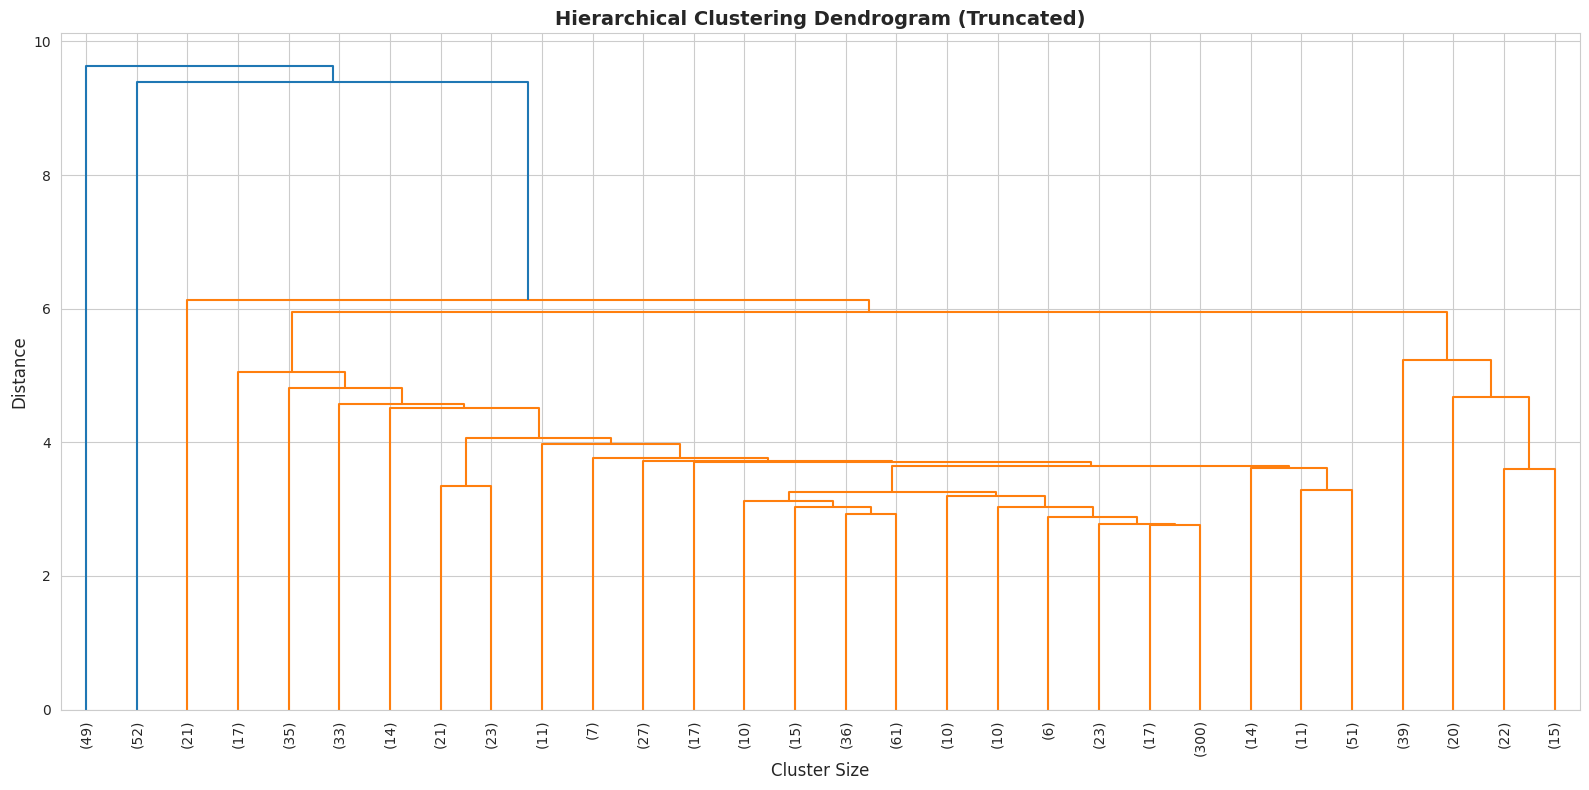

💾 Saved dendrogram to 'dendrogram.png'

🔍 Testing different numbers of clusters...
  k= 2 | Silhouette: 0.249 | Calinski-Harabasz: 99.4
  k= 3 | Silhouette: 0.268 | Calinski-Harabasz: 107.1
  k= 4 | Silhouette: 0.281 | Calinski-Harabasz: 90.2
  k= 5 | Silhouette: 0.221 | Calinski-Harabasz: 82.2
  k= 6 | Silhouette: 0.210 | Calinski-Harabasz: 75.6
  k= 7 | Silhouette: 0.223 | Calinski-Harabasz: 71.1
  k= 8 | Silhouette: 0.218 | Calinski-Harabasz: 67.7
  k= 9 | Silhouette: 0.227 | Calinski-Harabasz: 65.1
  k=10 | Silhouette: 0.226 | Calinski-Harabasz: 63.3
  k=11 | Silhouette: 0.236 | Calinski-Harabasz: 62.0
  k=12 | Silhouette: 0.235 | Calinski-Harabasz: 60.3
  k=13 | Silhouette: 0.243 | Calinski-Harabasz: 58.9
  k=14 | Silhouette: 0.252 | Calinski-Harabasz: 57.5
  k=15 | Silhouette: 0.254 | Calinski-Harabasz: 56.3
  k=16 | Silhouette: 0.258 | Calinski-Harabasz: 55.5
  k=17 | Silhouette: 0.260 | Calinski-Harabasz: 54.8
  k=18 | Silhouette: 0.266 | Calinski-Harabasz: 54.2
  k=19 | Silhou

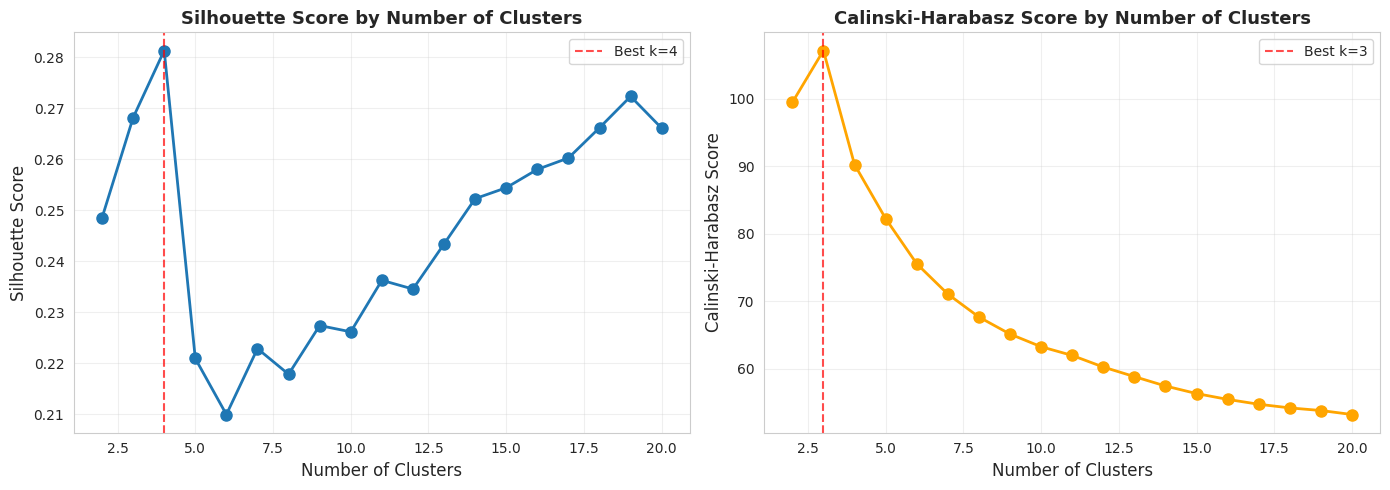

💾 Saved clustering metrics to 'clustering_metrics.png'

🎯 Recommended optimal k: 4 (based on Silhouette Score)
   Alternative k: 3 (based on Calinski-Harabasz Score)


In [19]:
print("\n" + "="*70)
print("🌳 HIERARCHICAL CLUSTERING")
print("="*70)

# Compute linkage matrix
print("Computing linkage matrix (this may take a while)...")
linkage_matrix = linkage(tfidf_reduced, method='ward')
print("✅ Linkage matrix computed")

# Plot dendrogram untuk lihat struktur cluster
plt.figure(figsize=(16, 8))
dendrogram(linkage_matrix, 
           truncate_mode='lastp',  # Show only last p merged clusters
           p=30,                    # Show last 30 merges
           leaf_rotation=90,
           leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Truncated)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Size', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved dendrogram to 'dendrogram.png'")

# Test different number of clusters
print("\n🔍 Testing different numbers of clusters...")
silhouette_scores = []
ch_scores = []
k_range = range(2, 21)  # Test dari 2 sampai 20 clusters

for k in k_range:
    clusterer = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels = clusterer.fit_predict(tfidf_reduced)
    
    # Compute metrics
    sil_score = silhouette_score(tfidf_reduced, cluster_labels)
    ch_score = calinski_harabasz_score(tfidf_reduced, cluster_labels)
    
    silhouette_scores.append(sil_score)
    ch_scores.append(ch_score)
    
    print(f"  k={k:2d} | Silhouette: {sil_score:.3f} | Calinski-Harabasz: {ch_score:.1f}")

# Plot metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, silhouette_scores, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score by Number of Clusters', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
best_k_sil = k_range[np.argmax(silhouette_scores)]
axes[0].axvline(best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_sil}')
axes[0].legend()

axes[1].plot(k_range, ch_scores, 'o-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Number of Clusters', fontsize=12)
axes[1].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1].set_title('Calinski-Harabasz Score by Number of Clusters', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
best_k_ch = k_range[np.argmax(ch_scores)]
axes[1].axvline(best_k_ch, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_ch}')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/clustering_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved clustering metrics to 'clustering_metrics.png'")

# Pilih k optimal (bisa dari silhouette atau CH score, atau kombinasi)
optimal_k = best_k_sil  # Anda bisa ganti ke best_k_ch atau nilai manual
print(f"\n🎯 Recommended optimal k: {optimal_k} (based on Silhouette Score)")
print(f"   Alternative k: {best_k_ch} (based on Calinski-Harabasz Score)")


🎯 APPLYING HIERARCHICAL CLUSTERING (k=4)
✅ Clustering completed with 4 clusters

Cluster distribution:
cluster_hierarchical
0    865
1     21
2     52
3     49
Name: count, dtype: int64


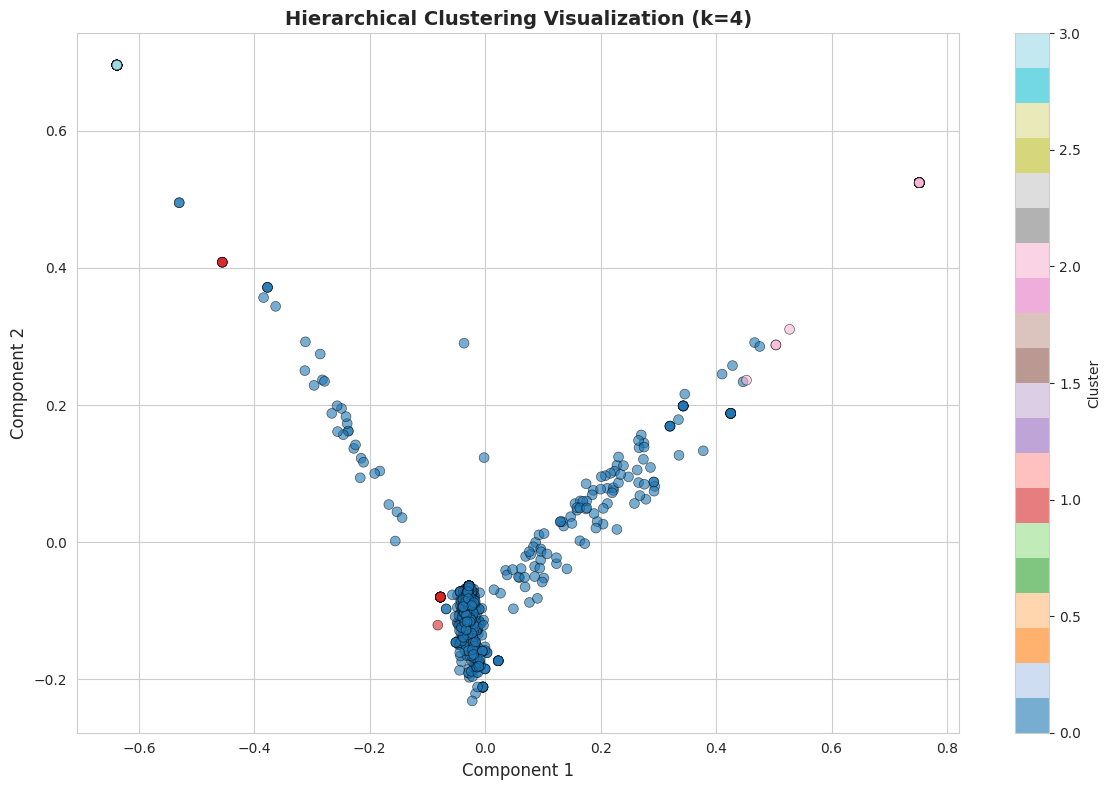

💾 Saved cluster visualization to 'clusters_visualization.png'


In [20]:
print("\n" + "="*70)
print(f"🎯 APPLYING HIERARCHICAL CLUSTERING (k=4)")
print("="*70)

# Apply clustering
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['cluster_hierarchical'] = hierarchical.fit_predict(tfidf_reduced)

print(f"✅ Clustering completed with 4 clusters")
print(f"\nCluster distribution:")
print(df['cluster_hierarchical'].value_counts().sort_index())

# Visualize clusters in 2D
plt.figure(figsize=(12, 8))
scatter = plt.scatter(coords_2d[:, 0], coords_2d[:, 1], 
                     c=df['cluster_hierarchical'], 
                     cmap='tab20', 
                     alpha=0.6, 
                     s=50,
                     edgecolors='black',
                     linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Component 1', fontsize=12)
plt.ylabel('Component 2', fontsize=12)
plt.title(f'Hierarchical Clustering Visualization (k=4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/clusters_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved cluster visualization to 'clusters_visualization.png'")

In [21]:
feature_names = vectorizer.get_feature_names_out()
print("\n" + "="*70)
print("📋 EXTRACTING TOP TERMS PER CLUSTER")
print("="*70)

def get_top_terms_per_cluster(df, tfidf_matrix, feature_names,
                              cluster_col='cluster_hierarchical', top_n=15):
    """Extract top terms for each cluster based on TF-IDF scores (robust to df index)."""
    clusters = np.unique(df[cluster_col])
    cluster_terms = {}
    n_docs = tfidf_matrix.shape[0]
    print(f"DEBUG: df rows = {len(df)}, tfidf_matrix.shape = {tfidf_matrix.shape}")

    for cluster_id in sorted(clusters):
        # get integer row positions (0..n-1) for documents in this cluster
        positions = np.where(df[cluster_col].values == cluster_id)[0]

        if positions.size == 0:
            continue

        # safety: ensure positions are within tfidf_matrix rows
        if positions.max() >= n_docs:
            raise IndexError(f"Position index {positions.max()} out of range for tfidf_matrix with {n_docs} rows")

        # slice tfidf_matrix by positional indices
        cluster_tfidf = tfidf_matrix[positions].mean(axis=0)

        # convert to 1d numpy array (works for sparse/dense)
        cluster_tfidf_array = np.asarray(cluster_tfidf).ravel()

        # Get top N terms
        top_indices = cluster_tfidf_array.argsort()[-top_n:][::-1]
        top_terms = [(feature_names[i], float(cluster_tfidf_array[i])) for i in top_indices]

        cluster_terms[cluster_id] = top_terms

    return cluster_terms

# Extract top terms
cluster_keywords = get_top_terms_per_cluster(df, tfidf_matrix, feature_names, 
                                             cluster_col='cluster_hierarchical', 
                                             top_n=15)

# Display results
for cluster_id, terms in cluster_keywords.items():
    num_reviews = len(df[df['cluster_hierarchical'] == cluster_id])
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id} ({num_reviews} reviews)")
    print(f"{'='*70}")
    print("Top keywords:")
    for term, score in terms:
        print(f"  • {term:25s} (TF-IDF: {score:.4f})")
    
    # Show sample reviews
    print("\nSample reviews (original):")
    sample_reviews = df[df['cluster_hierarchical'] == cluster_id]['content'].head(5).tolist()
    for i, review in enumerate(sample_reviews, 1):
        print(f"  {i}. {review[:150]}...")


📋 EXTRACTING TOP TERMS PER CLUSTER
DEBUG: df rows = 987, tfidf_matrix.shape = (987, 500)

CLUSTER 0 (865 reviews)
Top keywords:
  • sangat                    (TF-IDF: 0.0608)
  • shopee                    (TF-IDF: 0.0549)
  • bagus                     (TF-IDF: 0.0395)
  • baik                      (TF-IDF: 0.0380)
  • belanja                   (TF-IDF: 0.0378)
  • aplikasi                  (TF-IDF: 0.0331)
  • kirim                     (TF-IDF: 0.0303)
  • bantu                     (TF-IDF: 0.0299)
  • barang                    (TF-IDF: 0.0280)
  • sangat bantu              (TF-IDF: 0.0246)
  • banget                    (TF-IDF: 0.0240)
  • mudah                     (TF-IDF: 0.0237)
  • kasih                     (TF-IDF: 0.0188)
  • lebih                     (TF-IDF: 0.0186)
  • sangat bagus              (TF-IDF: 0.0182)

Sample reviews (original):
  1. aplikasi shopee ini sangat bagus karena. bisa mempermudah kita jika ingin belanja namun malas keluar rumah dan gratis ongkir lagi pok

In [22]:
import numpy as _np
def calculate_hierarchical_clustering(X_reduced):
    """
    Implementasi Persamaan 2.9 - 2.19
    Hierarchical Clustering dengan evaluasi
    """
    
    print("\n" + "="*100)
    print("BAGIAN 2: HIERARCHICAL CLUSTERING")
    print("Persamaan 2.9 - 2.19")
    print("="*100)
    
    # Persamaan 2.9: Euclidean Distance
    print("\n" + "-"*100)
    print("PERSAMAAN 2.9: Euclidean Distance")
    print("d(x_i, x_j) = √(Σ(x_il - x_jl)²)")
    print("-"*100)
    
    x_0 = X_reduced[0]
    x_1 = X_reduced[1]
    diff = x_0 - x_1
    squared = diff ** 2
    sum_sq = np.sum(squared)
    distance = np.sqrt(sum_sq)
    
    print(f"\nJarak antara Dok-0 dan Dok-1:")
    print(f"  Contoh dimensi 0: ({x_0[0]:.4f} - {x_1[0]:.4f})² = {squared[0]:.6f}")
    print(f"  Σ(squared diff) = {sum_sq:.6f}")
    print(f"  d = √{sum_sq:.6f} = {distance:.6f}")
    
    # Clustering dengan k=4
    k = 4
    hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels = hierarchical.fit_predict(X_reduced)
    
    print(f"\nClustering dengan k={k}:")
    for c in range(k):
        count = np.sum(cluster_labels == c)
        print(f"  Cluster {c}: {count} dokumen")
    
    # Persamaan 2.10: Centroid
    print("\n" + "-"*100)
    print("PERSAMAAN 2.10: Cluster Centroid")
    print("μ_C = (1/n_C) Σ x_i")
    print("-"*100)
    
    cluster_id = 0
    mask = cluster_labels == cluster_id
    points = X_reduced[mask]
    n_C = len(points)
    mu_C = np.mean(points, axis=0)
    
    print(f"\nCluster {cluster_id}:")
    print(f"  n_C = {n_C} dokumen")
    print(f"  μ_C[0] = (1/{n_C}) × Σ x[i,0] = {mu_C[0]:.6f}")
    # indeks dokumen di cluster 0
    idxs = np.where(cluster_labels == 0)[0]
    
    # nilai kolom-0 untuk dokumen cluster 0
    vals_col0 = X_reduced[idxs, 0]
    
    print("n_C =", len(idxs))
    print("10 nilai pertama kolom 0:", vals_col0[:10])
    print("sum =", vals_col0.sum())
    print("mean =", vals_col0.mean())
    print("std  =", vals_col0.std())
    
    # jumlah dimensi (jumlah elemen tiap vektor fitur)
    d = X_reduced.shape[1]
    
    # x0: dokumen indeks 0 (vektor)
    x0 = X_reduced[0]
    
    # mu_global (μ) — jika nanti sudah dihitung lagi di bawah, penghitungan ulang ini aman
    mu_global = np.mean(X_reduced, axis=0)
    
    # hitung/jelaskan berapa banyak elemen (count) pada tiap vektor
    print(f"  dimensi (d) = {d}")
    print(f"  jumlah elemen μ_C     = {mu_C.shape[0]}")
    print(f"  jumlah elemen x0      = {x0.shape[0]}")
    print(f"  jumlah elemen μ (global) = {mu_global.shape[0]}")
    
    # tampilkan 5 sampel pertama (ringkasan)
    print(f"  5 sampel pertama μ_C   = {np.round(mu_C[:5], 6)}")
    print(f"  5 sampel pertama x0    = {np.round(x0[:5], 6)}")
    print(f"  5 sampel pertama μ (global) = {np.round(mu_global[:5], 6)}")

    # Persamaan 2.11: WCSS
    print("\n" + "-"*100)
    print("PERSAMAAN 2.11: Within-Cluster Sum of Squares (WCSS)")
    print("WCSS(C) = Σ ||x_i - μ_C||²")
    print("-"*100)
    
    wcss = 0
    for i, idx in enumerate(np.where(mask)[0][:3]):   # tetap 3 dokumen contoh
        x_vec = X_reduced[idx]
        diff_vec = x_vec - mu_C
        dist = np.linalg.norm(diff_vec)
        sq_dist = dist ** 2
    
        print(f"\n  Dok {idx}:")
        print(f"    x[{idx}][:5]   = {np.round(x_vec[:5], 6)}")
        print(f"    μ_C[:5]        = {np.round(mu_C[:5], 6)}")
        print(f"    (x - μ)[:5]    = {np.round(diff_vec[:5], 6)}")
        print(f"    ||x - μ||      = {dist:.6f}")
        print(f"    ||x - μ||^2    = {sq_dist:.6f}")
    
    wcss_total = np.sum([np.linalg.norm(x - mu_C)**2 for x in points])
    print(f"  WCSS total = {wcss_total:.6f}")
    
    
    # Persamaan 2.12: Ward Linkage
    print("\n" + "-"*100)
    print("PERSAMAAN 2.12: Ward Linkage Δ(A,B)")
    print("Δ(A,B) = WCSS(A∪B) - WCSS(A) - WCSS(B)")
    print("-"*100)
    
    mask_A = cluster_labels == 0
    mask_B = cluster_labels == 1
    points_A = X_reduced[mask_A]
    points_B = X_reduced[mask_B]
    
    mu_A = np.mean(points_A, axis=0)
    mu_B = np.mean(points_B, axis=0)
    wcss_A = np.sum([np.linalg.norm(x - mu_A)**2 for x in points_A])
    wcss_B = np.sum([np.linalg.norm(x - mu_B)**2 for x in points_B])
    
    points_AB = np.vstack([points_A, points_B])
    mu_AB = np.mean(points_AB, axis=0)
    wcss_AB = np.sum([np.linalg.norm(x - mu_AB)**2 for x in points_AB])
    
    delta = wcss_AB - wcss_A - wcss_B
    
    print(f"\nΔ(Cluster 0, Cluster 1):")
    print(f"  WCSS(A) = {wcss_A:.6f}")
    print(f"  WCSS(B) = {wcss_B:.6f}")
    print(f"  WCSS(A∪B) = {wcss_AB:.6f}")
    print(f"  Δ = {wcss_AB:.6f} - {wcss_A:.6f} - {wcss_B:.6f} = {delta:.6f}")
    
    # Persamaan 2.13-2.14: Silhouette a(i) dan b(i)
    print("\n" + "-"*100)
    print("PERSAMAAN 2.13-2.14: Silhouette a(i) dan b(i)")
    print("-"*100)
    
    sample_idx = 0
    sample_cluster = cluster_labels[sample_idx]
    
    # a(i)
    same_mask = (cluster_labels == sample_cluster) & (np.arange(len(cluster_labels)) != sample_idx)
    same_points = X_reduced[same_mask]
    distances_same = [np.linalg.norm(X_reduced[sample_idx] - p) for p in same_points]
    a_i = np.mean(distances_same) if len(distances_same) > 0 else 0
    
    print(f"\nDokumen {sample_idx} (Cluster {sample_cluster}):")
    print(f"  a(i) = rata-rata jarak dalam cluster")
    print(f"  Contoh jarak: {distances_same[:3]}")
    print(f"  a(i) = {a_i:.6f}")
    
    # b(i)
    other_clusters = [c for c in range(k) if c != sample_cluster]
    min_dist = float('inf')
    for c in other_clusters:
        other_points = X_reduced[cluster_labels == c]
        avg_dist = np.mean([np.linalg.norm(X_reduced[sample_idx] - p) for p in other_points])
        if avg_dist < min_dist:
            min_dist = avg_dist
            nearest_cluster = c
    
    b_i = min_dist
    print(f"\n  b(i) = rata-rata jarak ke cluster terdekat")
    print(f"  Cluster terdekat: {nearest_cluster}")
    print(f"  b(i) = {b_i:.6f}")
    
    # Persamaan 2.15-2.16: Silhouette Score
    sample_idx = 0
    sample_cluster = cluster_labels[sample_idx]
    idxs_same_cluster = np.where(cluster_labels == sample_cluster)[0]
    idxs_same_cluster = idxs_same_cluster[idxs_same_cluster != sample_idx]  # exclude sample itself
    # a(i) — per-dokumen distances inside same cluster
    distances_same = []
    print(f"\nDokumen {sample_idx} (Cluster {sample_cluster}): menghitung a(i)")
    for j, idx in enumerate(idxs_same_cluster[:10]):  # tampilkan up to 10 jarak contoh
        d_j = np.linalg.norm(X_reduced[sample_idx] - X_reduced[idx])
        distances_same.append(d_j)
        print(f"  jarak ke dok {idx}: ||x[{sample_idx}] - x[{idx}]|| = {d_j:.6f}")
    
    # rata-rata a(i)
    if len(distances_same) > 0:
        a_i = np.mean(distances_same)
        print(f"  a(i) = mean({[round(v,6) for v in distances_same]}) = {a_i:.6f}")
    else:
        a_i = 0
        print("  a(i) = 0 (tidak ada anggota lain di cluster)")
    
    # b(i) — rata-rata jarak ke setiap cluster lain, lalu pilih minimum
    other_clusters = [c for c in range(k) if c != sample_cluster]
    avg_dists_per_cluster = {}
    print(f"\nMenghitung rata-rata jarak dari dokumen {sample_idx} ke tiap cluster lain (b(i) candidates):")
    for c in other_clusters:
        other_idxs = np.where(cluster_labels == c)[0]
        if other_idxs.size == 0:
            avg_dist = np.nan
            print(f"  Cluster {c}: kosong")
        else:
            dists = [np.linalg.norm(X_reduced[sample_idx] - X_reduced[idx]) for idx in other_idxs]
            avg_dist = np.mean(dists)
            # tampilkan beberapa contoh jarak (maks 6) untuk cluster c
            sample_dists = [round(v,6) for v in (dists[:6])]
            print(f"  Cluster {c}: n={len(other_idxs)}, contoh jarak={sample_dists} ..., rata-rata = {avg_dist:.6f}")
        avg_dists_per_cluster[c] = avg_dist
    
    # pilih cluster terdekat
    nearest_cluster = min(avg_dists_per_cluster, key=lambda cc: avg_dists_per_cluster[cc])
    b_i = avg_dists_per_cluster[nearest_cluster]
    print(f"\nCluster terdekat untuk dok {sample_idx} = {nearest_cluster} dengan b(i) = {b_i:.6f}")
    
    # s(i) per-step
    print("\n" + "-"*40)
    print("PERSAMAAN 2.15-2.16: Silhouette Score per-step")
    print("s(i) = (b(i) - a(i)) / max{a(i), b(i)}")
    print("-"*40)
    print(f"  a(i) = {a_i:.6f}")
    print(f"  b(i) = {b_i:.6f}")
    numerator = (b_i - a_i)
    denominator = max(a_i, b_i) if max(a_i, b_i) != 0 else np.nan
    s_i = numerator / denominator if denominator != 0 else 0
    print(f"  numerator = b(i) - a(i) = {b_i:.6f} - {a_i:.6f} = {numerator:.6f}")
    print(f"  denominator = max(a(i), b(i)) = {denominator:.6f}")
    print(f"  s({sample_idx}) = {numerator:.6f} / {denominator:.6f} = {s_i:.6f}")
    
    # Global silhouette (unchanged) — tampilkan juga ringkasan per-cluster mean s
    S = silhouette_score(X_reduced, cluster_labels)
    print(f"\nS (global) = (1/N) Σ s(i) = {S:.6f}")
    
    # Persamaan 2.17-2.19: Calinski-Harabasz
    print("\n" + "-"*100)
    print("PERSAMAAN 2.17-2.19: Calinski-Harabasz Index")
    print("-"*100)
    
    mu_global = np.mean(X_reduced, axis=0)
    n = len(X_reduced)
    
    # BCSS & wcss
    bcss = 0
    wcss_total_all = 0
    print("\nPer-cluster detail (n_k, ||μ_k - μ||^2, contribution n_k * ||μ_k - μ||^2, WCSS_k):")
    for c in range(k):
        mask_c = cluster_labels == c
        idxs_c = np.where(mask_c)[0]
        n_c = len(idxs_c)
        if n_c == 0:
            mu_c = np.zeros(mu_global.shape)
            norm_sq = 0.0
            wcss_c = 0.0
        else:
            mu_c = np.mean(X_reduced[mask_c], axis=0)
            diff_mu = mu_c - mu_global
            norm_sq = np.linalg.norm(diff_mu)**2
            wcss_c = np.sum([np.linalg.norm(X_reduced[idx] - mu_c)**2 for idx in idxs_c])
    
        contrib = n_c * norm_sq
        bcss += contrib
        wcss_total_all += wcss_c
    
        # print per-cluster breakdown (ringkasan)
        print(f"  Cluster {c}: n_k={n_c}")
        print(f"    μ_k[:5] = {np.round(mu_c[:5],6)}")
        print(f"    ||μ_k - μ||^2 = {norm_sq:.6f}")
        print(f"    n_k * ||μ_k - μ||^2 = {contrib:.6f}")
        print(f"    WCSS_k = {wcss_c:.6f}")
    
    # totals and CH calculation (show intermediate division)
    print(f"\nBCSS (sum n_k ||μ_k - μ||^2) = {bcss:.6f}")
    print(f"WCSS (sum per-cluster WCSS_k) = {wcss_total_all:.6f}")
    
    # CH index
    numerator_ch = bcss / (k - 1)
    denominator_ch = wcss_total_all / (n - k)
    ch = numerator_ch / denominator_ch if denominator_ch != 0 else np.nan
    
    print(f"\nCH(k) = (BCSS/(k-1)) / (WCSS/(n-k))")
    print(f"  BCSS/(k-1) = {bcss:.6f} / {k-1} = {numerator_ch:.6f}")
    print(f"  WCSS/(n-k) = {wcss_total_all:.6f} / {n-k} = {denominator_ch:.6f}")
    print(f"  CH({k}) = {numerator_ch:.6f} / {denominator_ch:.6f} = {ch:.6f}")

cluster_labels=calculate_hierarchical_clustering(X_reduced)


BAGIAN 2: HIERARCHICAL CLUSTERING
Persamaan 2.9 - 2.19

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.9: Euclidean Distance
d(x_i, x_j) = √(Σ(x_il - x_jl)²)
----------------------------------------------------------------------------------------------------

Jarak antara Dok-0 dan Dok-1:
  Contoh dimensi 0: (0.3675 - 0.0555)² = 0.097345
  Σ(squared diff) = 1.068522
  d = √1.068522 = 1.033694

Clustering dengan k=4:
  Cluster 0: 865 dokumen
  Cluster 1: 21 dokumen
  Cluster 2: 52 dokumen
  Cluster 3: 49 dokumen

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.10: Cluster Centroid
μ_C = (1/n_C) Σ x_i
----------------------------------------------------------------------------------------------------

Cluster 0:
  n_C = 865 dokumen
  μ_C[0] = (1/865) × Σ x[i,0] = 0.076184
n_C = 865
10 nilai pertama kolom 0: [3.67491145e-01 5.54899906e-02 3.35782285e-02 4.569